<h1 style="color:#2E86C1; text-align:center;">
Project: Spam Detection using Decision Trees
</h1>

<p style="text-align:center; font-size:18px;">
<b>Course:</b> Machine Learning (CS1461)
</p>

<p style="text-align:center; font-size:18px;">
<b>University:</b> Al-Imam Mohammad Ibn Saud Islamic University
</p>

<p style="text-align:center; font-size:18px;">
<b>College:</b> Computer and Information Sciences
</p>

<p style="text-align:center; font-size:18px;">
<b>Instructors:</b> Prof. Hachemi BinNaceur, Abeer Alsheddi, Dr. Ahmed GadALLAH
</p>

<p style="text-align:center; color:gray; font-size:16px;">
Due Date: May 9, 2026
</p>

<h2 style="color:#2E86C1;">1. Goal</h2>

<p style="font-size:17px;">
In this project, we use a <b>Decision Tree</b> to classify emails as
<b style="color:#e74c3c;">Spam</b> or
<b style="color:#27ae60;">Not Spam</b>.
</p>

<p style="font-size:17px;">We will:</p>

<ul style="font-size:16px;">
  <li>See if <b>normalization</b> changes the results.</li>
  <li>Check <b>overfitting</b> using training and validation.</li>
  <li>Fix <b>imbalanced data</b>.</li>
  <li>Draw the tree and understand the results.</li>
</ul>

<h2 style="color:#2E86C1;">2. Imports</h2>



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample

%matplotlib inline
sns.set(style="whitegrid")


<h2 style="color:#2E86C1;">3. Loading the Dataset</h2>



In [ ]:
# Read column names from spambase.names, then load the CSV data
columns = []
with open('spambase.names', 'r') as f:
    content = f.read()
    found_names = re.findall(r'^([\w\(\);!$#\[\]\-]+):', content, re.MULTILINE)
    columns = [name.strip() for name in found_names]

columns.append('spam')  # Add target column
df = pd.read_csv('spambase.data', names=columns)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


<h2 style="color:#2E86C1;">4. Dataset Overview </h2>


Class Distribution (Original Dataset):
spam
0    2788
1    1813
Name: count, dtype: int64

Spam:     39.40%
Not Spam: 60.60%


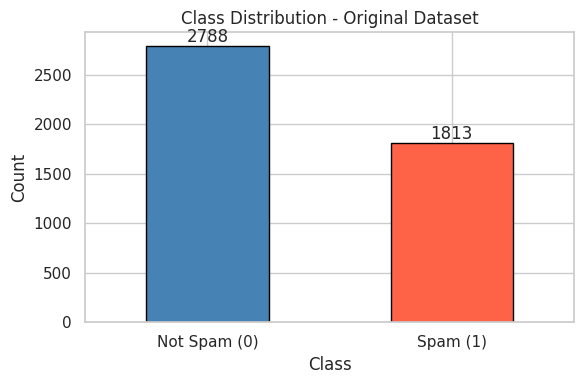

In [ ]:
# Show class distribution to identify any imbalance
print("Class Distribution (Original Dataset):")
print(df['spam'].value_counts())
print(f"\nSpam:     {df['spam'].mean()*100:.2f}%")
print(f"Not Spam: {(1 - df['spam'].mean())*100:.2f}%")

# Bar chart to visualize class imbalance
plt.figure(figsize=(6, 4))
ax = df['spam'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['Not Spam (0)', 'Spam (1)'], rotation=0)
plt.title("Class Distribution - Original Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()




<h2 style="color:#2E86C1;">5. Data Splitting (Train /  Val /  Test) </h2>




In [ ]:

# Step 1: Separate features and target
X = df.drop('spam', axis=1)
y = df['spam']

# Step 2: Split data into 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 3: Split temporary data into 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Step 4: Display dataset sizes
print("DATA SPLIT SUMMARY")
print(f"Training set:   {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing set:    {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification preserved class ratio
print("\nSpam % Across Splits:")
print(f"  Original:   {y.mean()*100:.2f}%")
print(f"  Train:      {y_train.mean()*100:.2f}%")
print(f"  Validation: {y_val.mean()*100:.2f}%")
print(f"  Test:       {y_test.mean()*100:.2f}%")




DATA SPLIT SUMMARY
Training set:   (3220, 57) (70.0%)
Validation set: (690, 57) (15.0%)
Testing set:    (691, 57) (15.0%)

Spam % Across Splits:
  Original:   39.40%
  Train:      39.41%
  Validation: 39.42%
  Test:       39.36%


<h2 style="color:#2E86C1;">CASE 1: Normalization — Without vs With</h2>








  CASE 1-A: Without Normalization
  Train Accuracy      : 0.9997
  Validation Accuracy : 0.9058
  Test Accuracy       : 0.8784


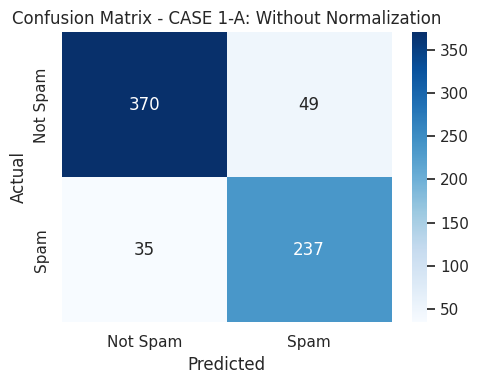

              precision    recall  f1-score   support

    Not Spam       0.91      0.88      0.90       419
        Spam       0.83      0.87      0.85       272

    accuracy                           0.88       691
   macro avg       0.87      0.88      0.87       691
weighted avg       0.88      0.88      0.88       691


  CASE 1-B: With MinMax Normalization
  Train Accuracy      : 0.9997
  Validation Accuracy : 0.9058
  Test Accuracy       : 0.8784


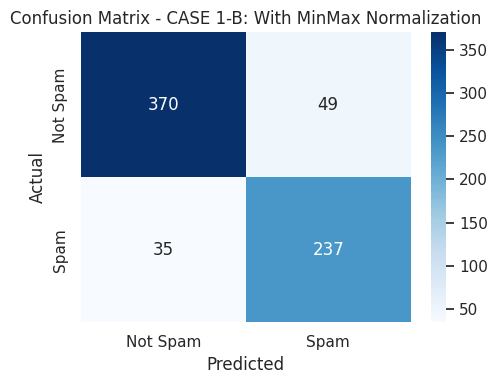

              precision    recall  f1-score   support

    Not Spam       0.91      0.88      0.90       419
        Spam       0.83      0.87      0.85       272

    accuracy                           0.88       691
   macro avg       0.87      0.88      0.87       691
weighted avg       0.88      0.88      0.88       691


--- Case 1 Comparison ---
Metric                       Without Norm       With Norm
-------------------------------------------------------
Train Accuracy                     0.9997          0.9997
Validation Accuracy                0.9058          0.9058
Test Accuracy                      0.8784          0.8784


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

def train_evaluate_model(X_train, X_val, X_test,
                         y_train, y_val, y_test,
                         title="Model",
                         max_depth=None):
    # Train model
    model = DecisionTreeClassifier(random_state=42, max_depth=max_depth)
    model.fit(X_train, y_train)

    # Accuracies
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    vl_acc = accuracy_score(y_val,   model.predict(X_val))
    ts_acc = accuracy_score(y_test,  model.predict(X_test))

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Train Accuracy      : {tr_acc:.4f}")
    print(f"  Validation Accuracy : {vl_acc:.4f}")
    print(f"  Test Accuracy       : {ts_acc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Spam', 'Spam'],
                yticklabels=['Not Spam', 'Spam'])
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Classification report
    print(classification_report(y_test, model.predict(X_test),
                                target_names=['Not Spam', 'Spam']))

    return model, tr_acc, vl_acc, ts_acc


from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# CASE 1-A: Raw features, no scaling
model_base, tr_base, vl_base, ts_base = train_evaluate_model(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    title="CASE 1-A: Without Normalization"
)

# CASE 1-B: Scale all features to [0, 1] using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit only on train to avoid data leakage
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

model_norm, tr_norm, vl_norm, ts_norm = train_evaluate_model(
    X_train_scaled, X_val_scaled, X_test_scaled,
    y_train, y_val, y_test,
    title="CASE 1-B: With MinMax Normalization"
)

# Side-by-side comparison
print("\n--- Case 1 Comparison ---")
print(f"{'Metric':<25} {'Without Norm':>15} {'With Norm':>15}")
print("-" * 55)
print(f"{'Train Accuracy':<25} {tr_base:>15.4f} {tr_norm:>15.4f}")
print(f"{'Validation Accuracy':<25} {vl_base:>15.4f} {vl_norm:>15.4f}")
print(f"{'Test Accuracy':<25} {ts_base:>15.4f} {ts_norm:>15.4f}")

<h2 style="color:#2E86C1;">CASE 2: Overfitting — Without vs With Pruning</h2>



  CASE 2-A: Without Addressing Overfitting (Full Tree)
  Train Accuracy      : 0.9997
  Validation Accuracy : 0.9058
  Test Accuracy       : 0.8784


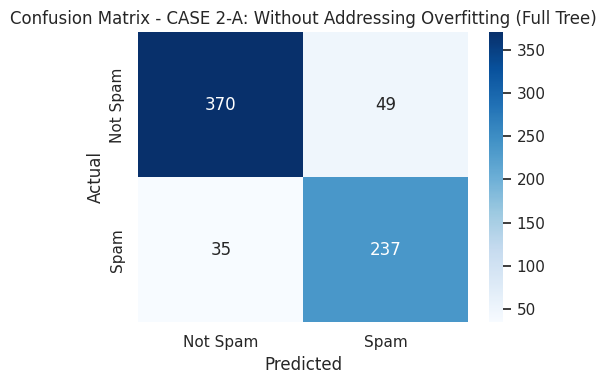

              precision    recall  f1-score   support

    Not Spam       0.91      0.88      0.90       419
        Spam       0.83      0.87      0.85       272

    accuracy                           0.88       691
   macro avg       0.87      0.88      0.87       691
weighted avg       0.88      0.88      0.88       691



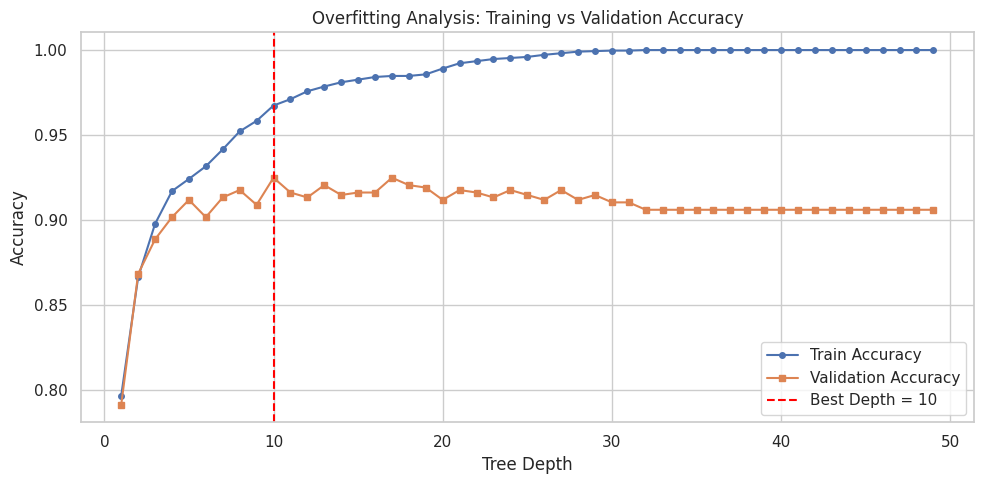


Best tree depth (highest validation accuracy): 10

  CASE 2-B: With Pruning (max_depth=10)
  Train Accuracy      : 0.9671
  Validation Accuracy : 0.9246
  Test Accuracy       : 0.9103


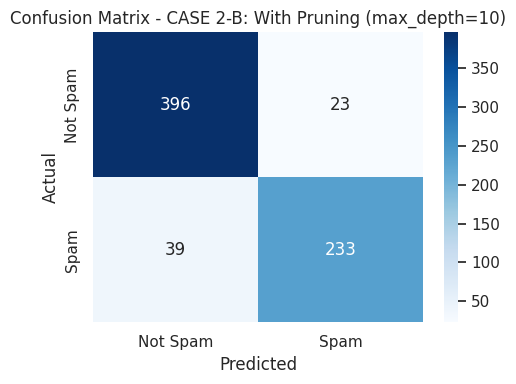

              precision    recall  f1-score   support

    Not Spam       0.91      0.95      0.93       419
        Spam       0.91      0.86      0.88       272

    accuracy                           0.91       691
   macro avg       0.91      0.90      0.90       691
weighted avg       0.91      0.91      0.91       691


--- Case 2 Comparison ---
Metric                          Full Tree     Pruned Tree
-------------------------------------------------------
Train Accuracy                     0.9997          0.9671
Validation Accuracy                0.9058          0.9246
Test Accuracy                      0.8784          0.9103


In [ ]:

# CASE 2-A: Full tree with no depth limit (likely overfits)
model_full, tr_full, vl_full, ts_full = train_evaluate_model(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    title="CASE 2-A: Without Addressing Overfitting (Full Tree)"
)

# Find best depth by tracking validation accuracy across depths
train_scores, val_scores = [], []
depths = range(1, 50)
best_depth, best_val_score = None, float('-inf')

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    v = dt.score(X_val, y_val)
    val_scores.append(v)
    if v > best_val_score:
        best_val_score = v
        best_depth = d

# Plot to visualize where overfitting begins
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o', markersize=4)
plt.plot(depths, val_scores,   label='Validation Accuracy', marker='s', markersize=4)
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Best Depth = {best_depth}')
plt.title("Overfitting Analysis: Training vs Validation Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest tree depth (highest validation accuracy): {best_depth}")

# CASE 2-B: Pruned tree using the best depth found above
model_pruned, tr_pruned, vl_pruned, ts_pruned = train_evaluate_model(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    title=f"CASE 2-B: With Pruning (max_depth={best_depth})",
    max_depth=best_depth
)

# Side-by-side comparison
print("\n--- Case 2 Comparison ---")
print(f"{'Metric':<25} {'Full Tree':>15} {'Pruned Tree':>15}")
print("-" * 55)
print(f"{'Train Accuracy':<25} {tr_full:>15.4f} {tr_pruned:>15.4f}")
print(f"{'Validation Accuracy':<25} {vl_full:>15.4f} {vl_pruned:>15.4f}")
print(f"{'Test Accuracy':<25} {ts_full:>15.4f} {ts_pruned:>15.4f}")

<h2 style="color:#2E86C1;">CASE 3: Bias — Unbalanced vs Balanced Dataset</h2>



Class Distribution — Unbalanced (Original):
spam
0    2788
1    1813
Name: count, dtype: int64

  CASE 3-A: Unbalanced Dataset (Original)
  Train Accuracy      : 0.9997
  Validation Accuracy : 0.9058
  Test Accuracy       : 0.8784


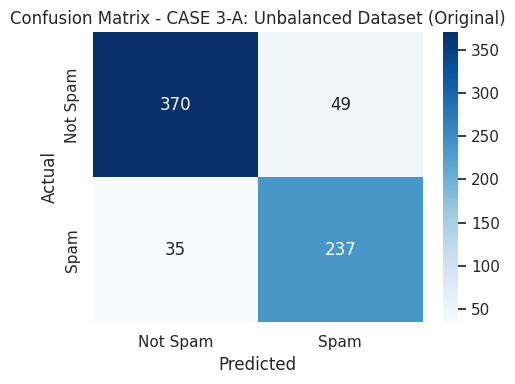

              precision    recall  f1-score   support

    Not Spam       0.91      0.88      0.90       419
        Spam       0.83      0.87      0.85       272

    accuracy                           0.88       691
   macro avg       0.87      0.88      0.87       691
weighted avg       0.88      0.88      0.88       691


Class Distribution — Balanced — Downsampling:
spam
1    1813
0    1813
Name: count, dtype: int64

  CASE 3: Balanced — Downsampling
  Train Accuracy      : 0.9996
  Validation Accuracy : 0.8971
  Test Accuracy       : 0.8897


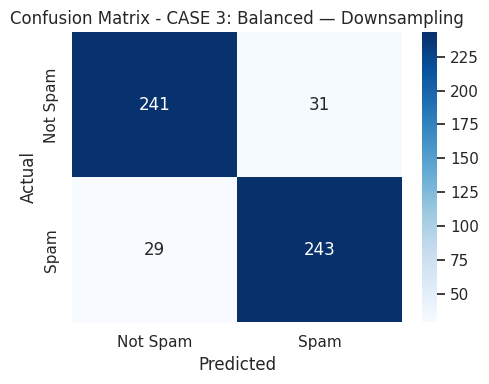

              precision    recall  f1-score   support

    Not Spam       0.89      0.89      0.89       272
        Spam       0.89      0.89      0.89       272

    accuracy                           0.89       544
   macro avg       0.89      0.89      0.89       544
weighted avg       0.89      0.89      0.89       544


Class Distribution — Balanced — Upsampling:
spam
1    2788
0    2788
Name: count, dtype: int64

  CASE 3: Balanced — Upsampling
  Train Accuracy      : 1.0000
  Validation Accuracy : 0.9522
  Test Accuracy       : 0.9331


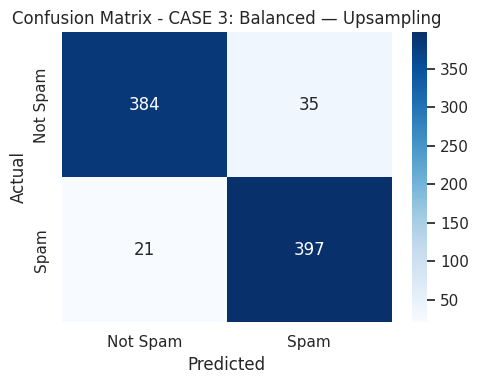

              precision    recall  f1-score   support

    Not Spam       0.95      0.92      0.93       419
        Spam       0.92      0.95      0.93       418

    accuracy                           0.93       837
   macro avg       0.93      0.93      0.93       837
weighted avg       0.93      0.93      0.93       837



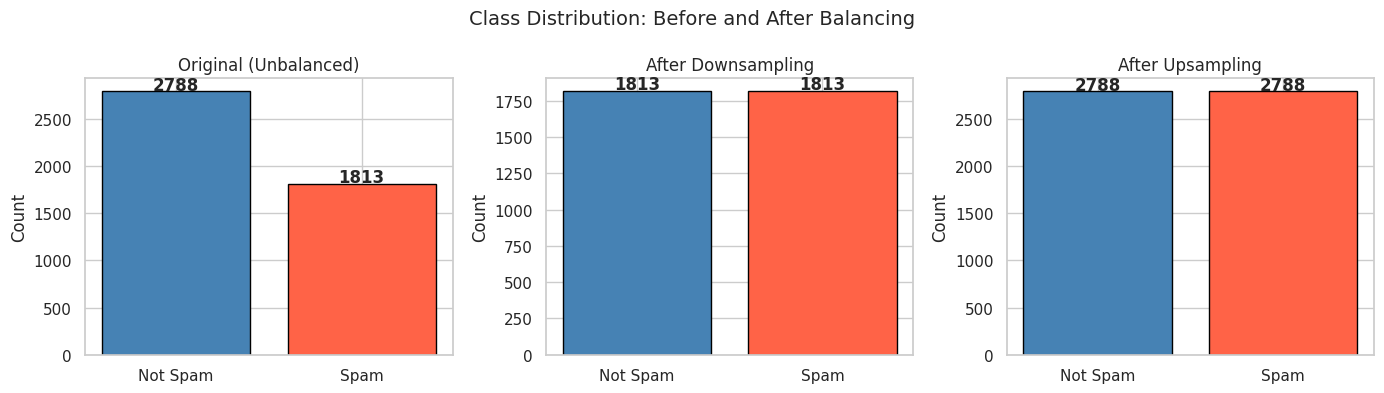


--- Case 3 Comparison ---
Metric                      Unbalanced   Downsample     Upsample
---------------------------------------------------------------
Train Accuracy                  0.9997       0.9996       1.0000
Validation Accuracy             0.9058       0.8971       0.9522
Test Accuracy                   0.8784       0.8897       0.9331


In [ ]:

# CASE 3-A: Train on original imbalanced data as baseline
print("\nClass Distribution — Unbalanced (Original):")
print(df['spam'].value_counts())

model_unbal, tr_unbal, vl_unbal, ts_unbal = train_evaluate_model(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
    title="CASE 3-A: Unbalanced Dataset (Original)"
)

# Helper: balance data, split it, then train and evaluate
def balance_and_evaluate(balanced_df, label):
    X_b = balanced_df.drop('spam', axis=1)
    y_b = balanced_df['spam']

    print(f"\nClass Distribution — {label}:")
    print(y_b.value_counts())

    X_tr_b, X_tmp_b, y_tr_b, y_tmp_b = train_test_split(
        X_b, y_b, test_size=0.30, random_state=42, stratify=y_b
    )
    X_vl_b, X_ts_b, y_vl_b, y_ts_b = train_test_split(
        X_tmp_b, y_tmp_b, test_size=0.50, random_state=42, stratify=y_tmp_b
    )

    result = train_evaluate_model(
        X_tr_b, X_vl_b, X_ts_b,
        y_tr_b, y_vl_b, y_ts_b,
        title=f"CASE 3: {label}"
    )
    return result, X_tr_b, y_tr_b

spam_cls     = df[df['spam'] == 1]
not_spam_cls = df[df['spam'] == 0]

# CASE 3-B: Downsample majority class to match minority
not_spam_down = resample(not_spam_cls, replace=False,
                          n_samples=len(spam_cls), random_state=42)
balanced_down = pd.concat([spam_cls, not_spam_down]).sample(frac=1, random_state=42)

(model_down, tr_down, vl_down, ts_down), X_tr_down, y_tr_down = \
    balance_and_evaluate(balanced_down, "Balanced — Downsampling")

# CASE 3-C: Upsample minority class to match majority
spam_up = resample(spam_cls, replace=True,
                   n_samples=len(not_spam_cls), random_state=42)
balanced_up = pd.concat([not_spam_cls, spam_up]).sample(frac=1, random_state=42)

(model_up, tr_up, vl_up, ts_up), X_tr_up, y_tr_up = \
    balance_and_evaluate(balanced_up, "Balanced — Upsampling")

# Plot class distribution: before and after balancing
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [df['spam'], balanced_down['spam'], balanced_up['spam']],
    ['Original (Unbalanced)', 'After Downsampling', 'After Upsampling']
):
    counts = data.value_counts().sort_index()
    ax.bar(['Not Spam', 'Spam'], counts.values,
           color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle("Class Distribution: Before and After Balancing", fontsize=14)
plt.tight_layout()
plt.show()

# Side-by-side comparison
print("\n--- Case 3 Comparison ---")
print(f"{'Metric':<25} {'Unbalanced':>12} {'Downsample':>12} {'Upsample':>12}")
print("-" * 63)
print(f"{'Train Accuracy':<25} {tr_unbal:>12.4f} {tr_down:>12.4f} {tr_up:>12.4f}")
print(f"{'Validation Accuracy':<25} {vl_unbal:>12.4f} {vl_down:>12.4f} {vl_up:>12.4f}")
print(f"{'Test Accuracy':<25} {ts_unbal:>12.4f} {ts_down:>12.4f} {ts_up:>12.4f}")




<h2 style="color:#2E86C1;">9. Final Model: Pruned + Upsampled</h2>



===== FINAL MODEL (Pruned + Upsampled Data) =====
Train Accuracy:      0.9641
Validation Accuracy: 0.9366
Test Accuracy:       0.9259

--- Final Classification Report ---
              precision    recall  f1-score   support

    Not Spam       0.93      0.92      0.93       419
        Spam       0.92      0.93      0.93       418

    accuracy                           0.93       837
   macro avg       0.93      0.93      0.93       837
weighted avg       0.93      0.93      0.93       837



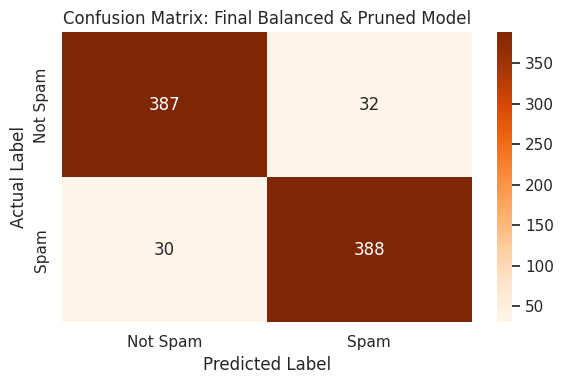

In [ ]:
# ── Final Step: Optimized Model (Pruned + Upsampled) ──────────────────────

# Step 1: Re-split the upsampled balanced dataset into train, validation, and test sets
X_b = balanced_up.drop('spam', axis=1)
y_b = balanced_up['spam']

X_train_b, X_tmp_b, y_train_b, y_tmp_b = train_test_split(
    X_b, y_b, test_size=0.30, random_state=42, stratify=y_b
)
X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(
    X_tmp_b, y_tmp_b, test_size=0.50, random_state=42, stratify=y_tmp_b
)

# Step 2: Build the final model using the best depth found in the overfitting analysis
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train_b, y_train_b)

# Step 3: Generate predictions for all splits
y_train_pred = final_model.predict(X_train_b)
y_val_pred   = final_model.predict(X_val_b)
y_test_pred  = final_model.predict(X_test_b)

# Step 4: Display accuracy for all splits
print("\n===== FINAL MODEL (Pruned + Upsampled Data) =====")
print(f"Train Accuracy:      {accuracy_score(y_train_b, y_train_pred):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_b, y_val_pred):.4f}")
print(f"Test Accuracy:       {accuracy_score(y_test_b, y_test_pred):.4f}")

# Step 5: Print the final classification report on the test set
print("\n--- Final Classification Report ---")
print(classification_report(y_test_b, y_test_pred,
                            target_names=['Not Spam', 'Spam']))

# Step 6: Plot the confusion matrix for the final model
cm = confusion_matrix(y_test_b, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title("Confusion Matrix: Final Balanced & Pruned Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

<h2 style="color:#2E86C1;">10. Decision Tree Visualization and Rule Extraction</h2>


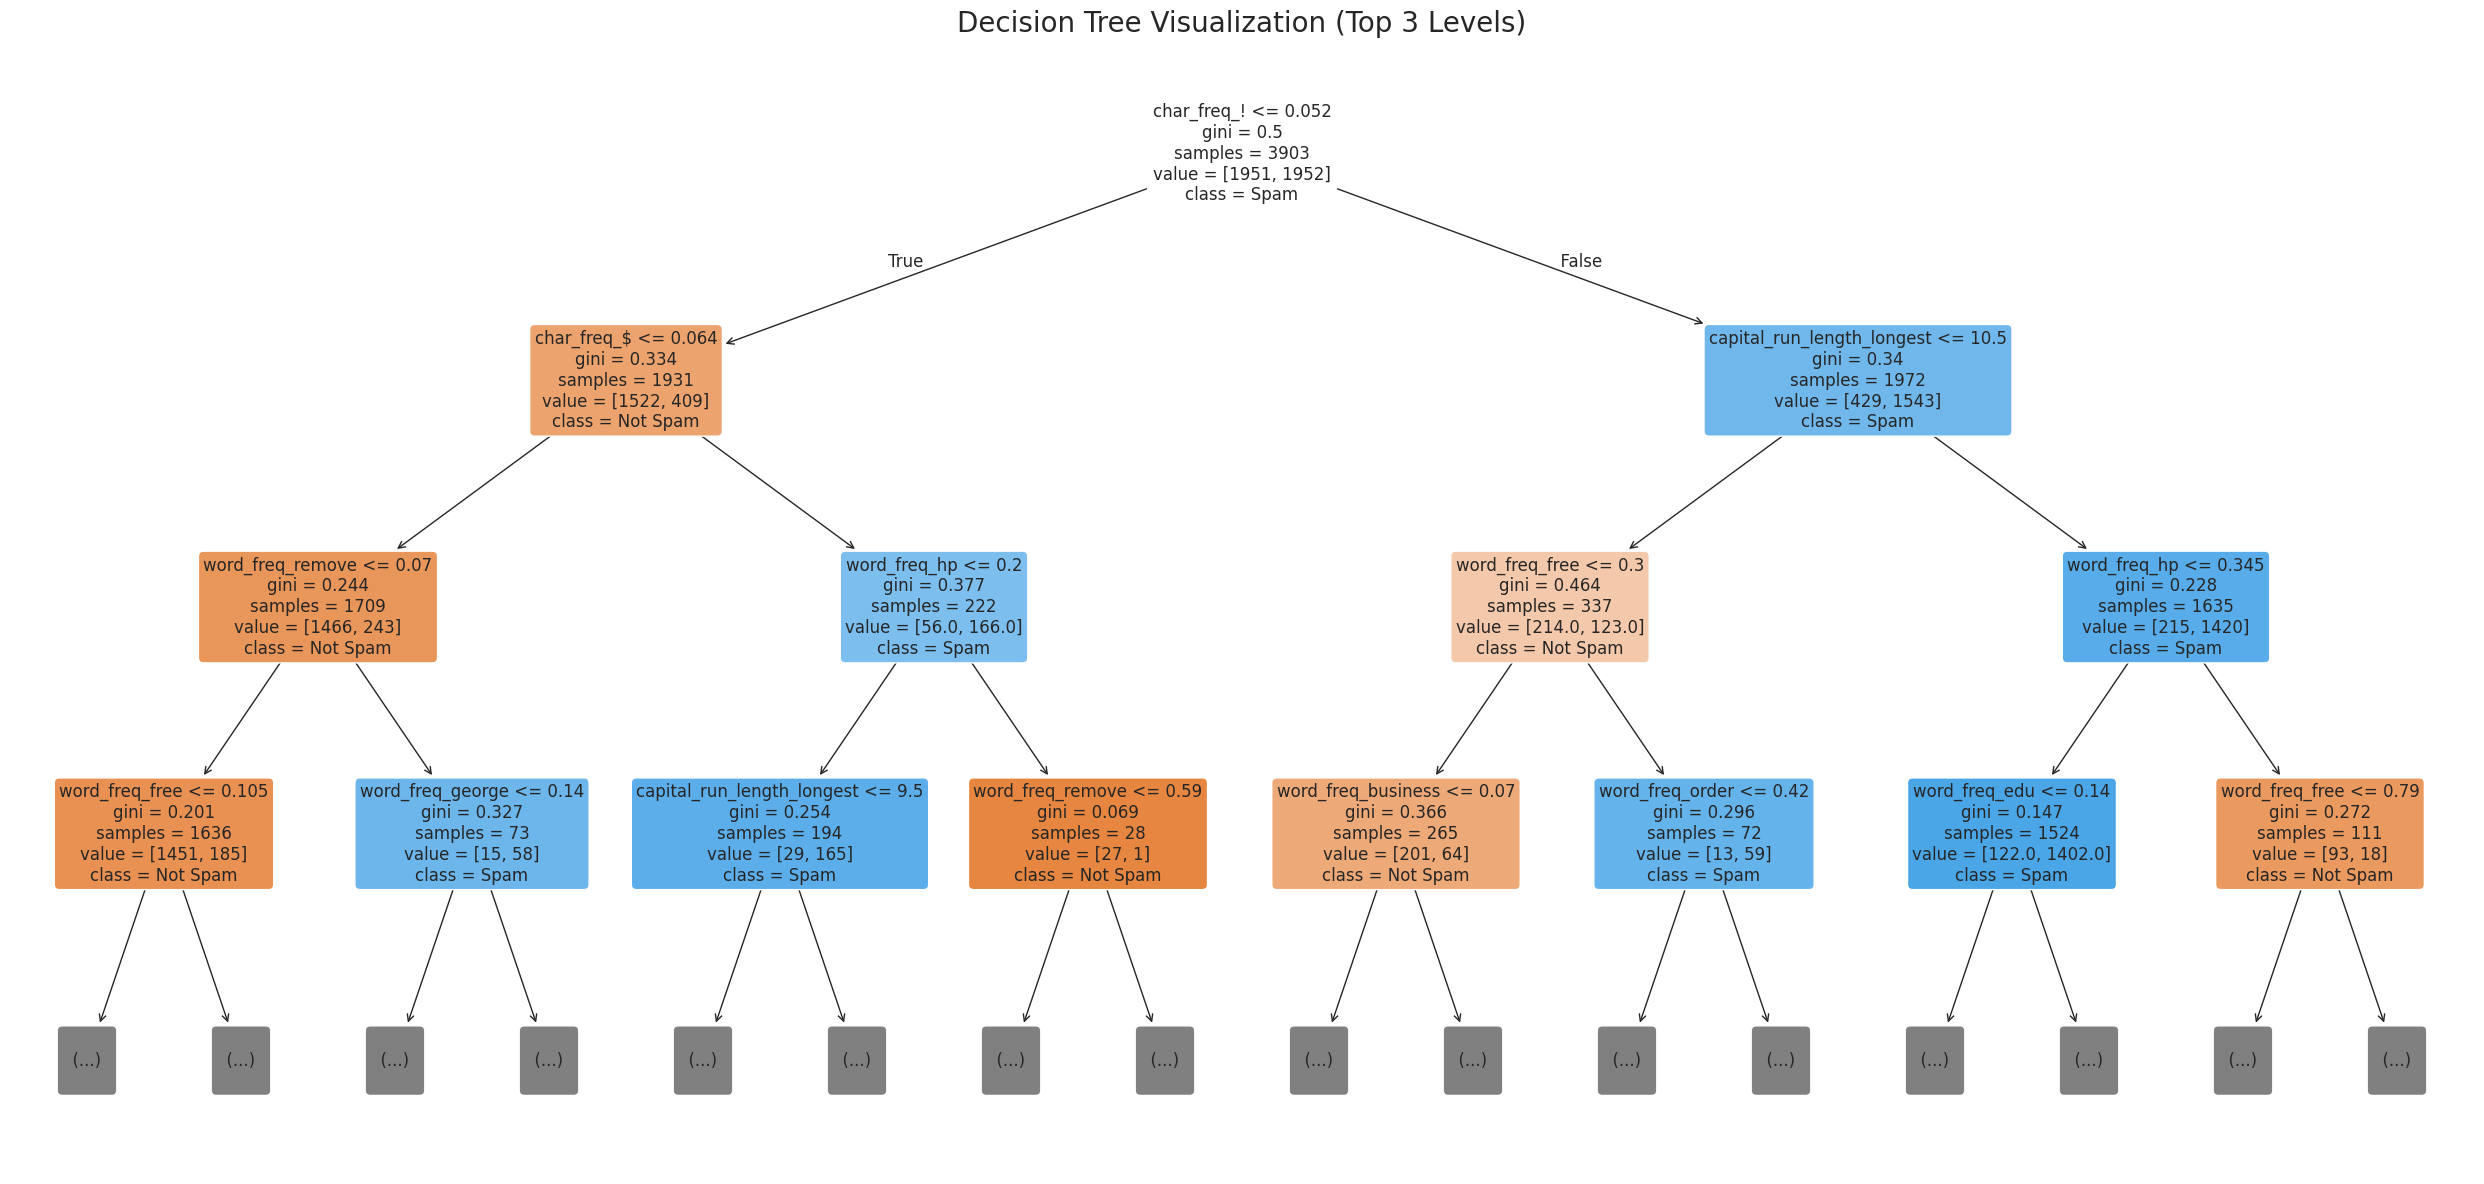

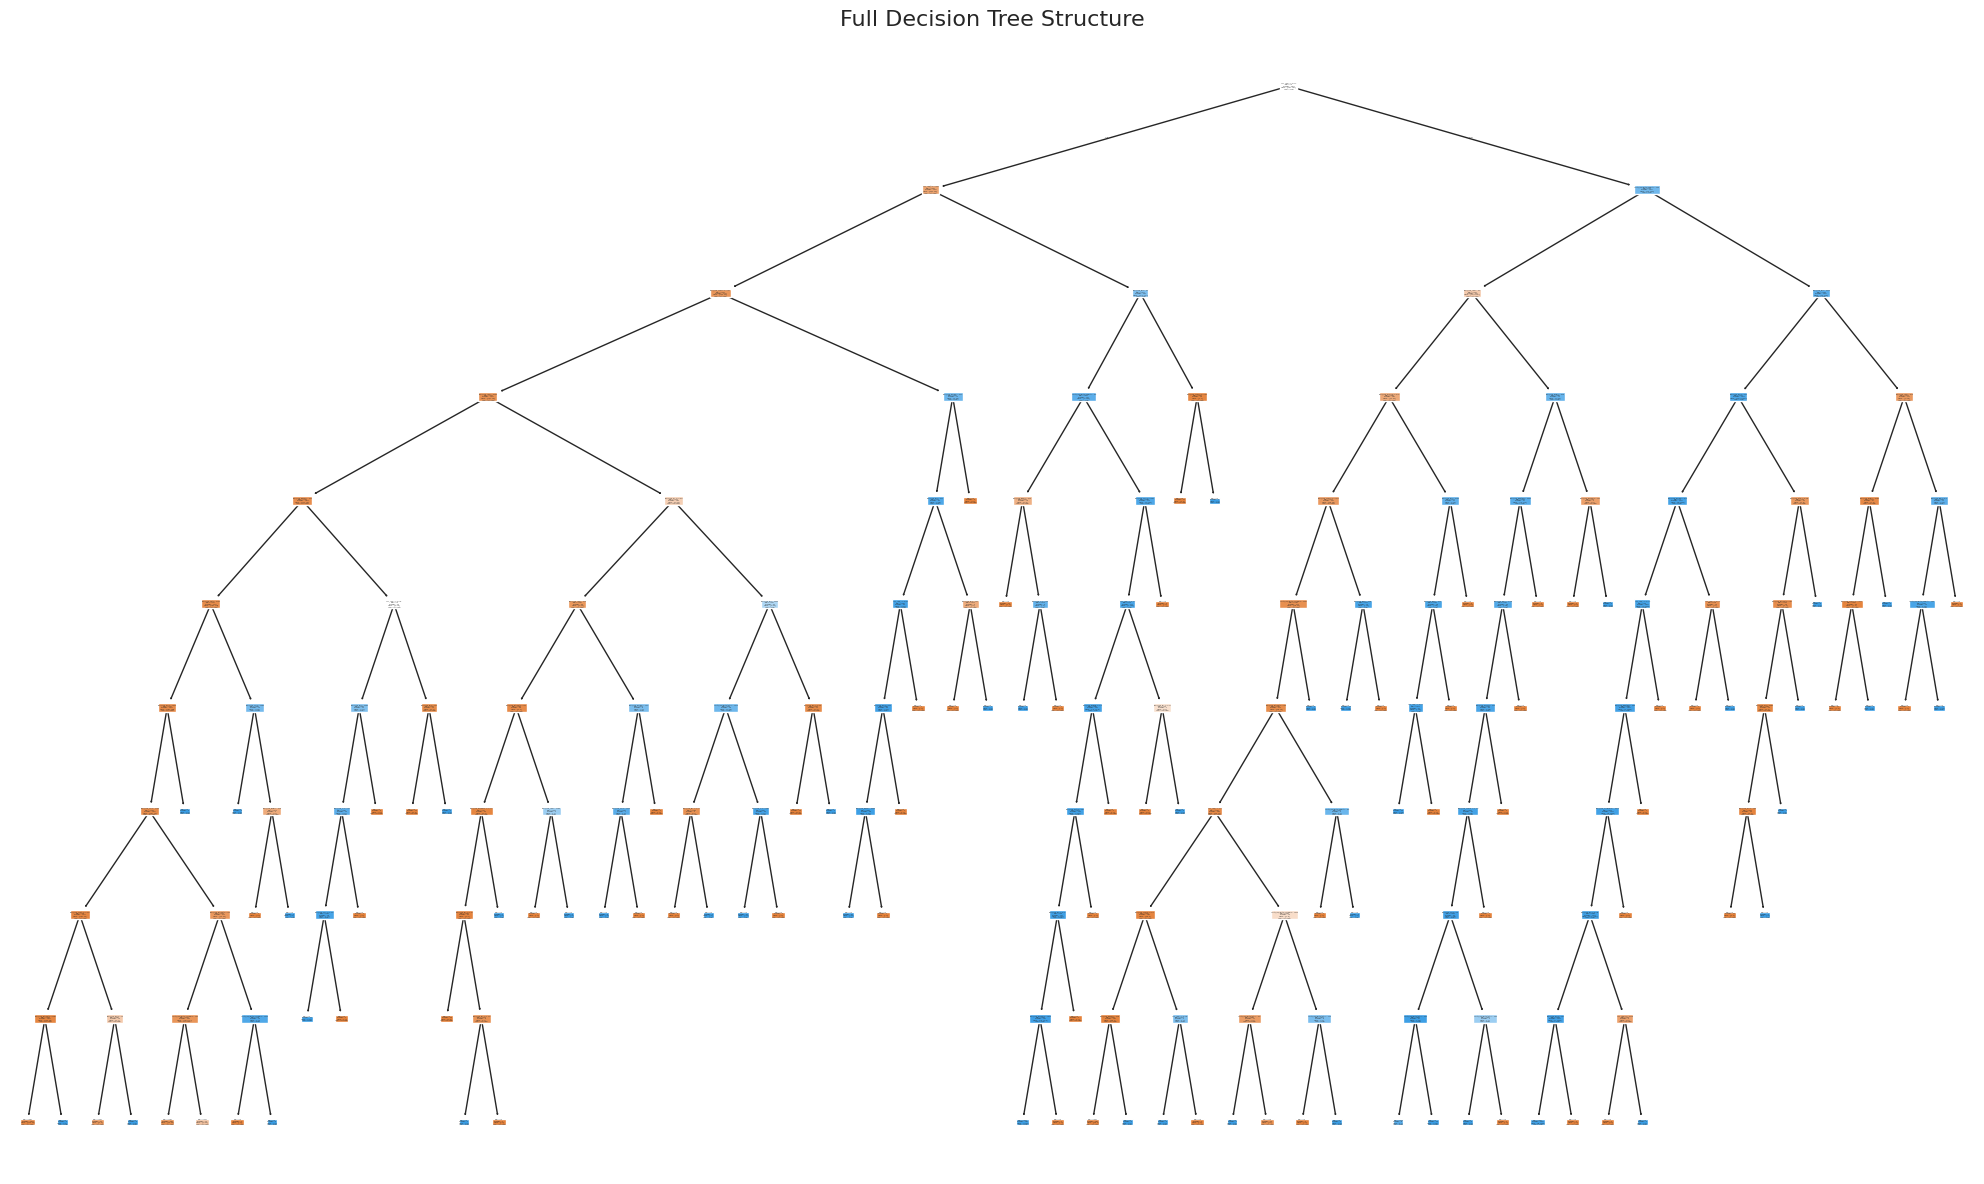


===== DECISION TREE RULES (Top 5 Levels) =====

|--- char_freq_! <= 0.05
|   |--- char_freq_$ <= 0.06
|   |   |--- word_freq_remove <= 0.07
|   |   |   |--- word_freq_free <= 0.11
|   |   |   |   |--- word_freq_money <= 0.01
|   |   |   |   |   |--- word_freq_font <= 0.16
|   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |--- word_freq_font >  0.16
|   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- word_freq_money >  0.01
|   |   |   |   |   |--- char_freq_( <= 0.07
|   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |--- char_freq_( >  0.07
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- word_freq_free >  0.11
|   |   |   |   |--- word_freq_our <= 0.10
|   |   |   |   |   |--- word_freq_free <= 4.23
|   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |--- word_freq_free >  4.23
|   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- w

In [ ]:
# CASE 4: Tree Visualization and Rule Extraction
# This section fulfills the requirement to visualize the decision logic
# and convert it into a set of rules.

from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# --- 1) Visualize the top levels of the tree ---
# We limit max_depth to 3 for the report to ensure the nodes and text are legible.
plt.figure(figsize=(25, 12))
plot_tree(
    final_model,
    max_depth=3,                       # Limit depth for better visibility in the report
    feature_names=list(X_train_b.columns),
    class_names=['Not Spam', 'Spam'],
    filled=True,                       # Color nodes by class
    rounded=True,                      # Rounded corners for aesthetics
    fontsize=12
)
plt.title("Decision Tree Visualization (Top 3 Levels)", fontsize=20)
plt.tight_layout()
plt.show()

# --- 2) Visualize the full tree ---
# Note: This might be very dense if the tree is deep.
plt.figure(figsize=(20, 12))
plot_tree(
    final_model,
    feature_names=list(X_train_b.columns),
    class_names=['Not Spam', 'Spam'],
    filled=True
)
plt.title("Full Decision Tree Structure", fontsize=16)
plt.tight_layout()
plt.show()

# --- 3) Extract and print the decision rules ---
# This converts the tree into human-readable if/else rules
print("\n===== DECISION TREE RULES (Top 5 Levels) =====\n")
rules = export_text(
    final_model,
    feature_names=list(X_train_b.columns),
    max_depth=5                        # Limit rules to top 5 levels for readability
)
print(rules)

# --- 4) Save rules to a text file for the report ---
with open("decision_tree_rules.txt", "w") as f:
    f.write(rules)
print("Rules saved to: decision_tree_rules.txt")